In [8]:
# 数据根目录：和 config/base.yaml 里 dataset.root 一致（项目根下的 data/）
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# 使用支持中文的字体，避免 "missing glyph" 警告和标题/图例中的方框
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Heiti SC", "Arial Unicode MS", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

# 若 notebook 在项目根运行，数据在 data/<user_id>/ 下
DATA_ROOT = Path("data")
USER_ID = "89335547"  # 与 config/user/single_user.yaml 里一致
# 用 single_user 里 test 的一个 session 做示例
SESSION_NAME = "2021-06-02-1622682789-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f"
hdf5_path = DATA_ROOT / USER_ID / f"{SESSION_NAME}.hdf5"
print("HDF5 path:", hdf5_path)
print("存在?", hdf5_path.exists())
# 列出该用户下已有 .hdf5 数量
user_dir = DATA_ROOT / USER_ID
if user_dir.exists():
    existing = list(user_dir.glob("*.hdf5"))
    print("data/{} 下 .hdf5 数量: {}".format(USER_ID, len(existing)))

HDF5 path: data/89335547/2021-06-02-1622682789-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f.hdf5
存在? True
data/89335547 下 .hdf5 数量: 18


In [17]:
# 直接看 HDF5 源文件长什么样：结构 + 特征字段 + target 字段（截短）
import h5py
import json

with h5py.File(hdf5_path, "r") as f:
    print("=== 顶层 keys ===")
    print(list(f.keys()))

    g = f["emg2qwerty"]
    print("\n=== emg2qwerty 组内 keys ===")
    print(list(g.keys()))

    # ---------- 特征：timeseries（一条连续时序，每行一个时间点）
    ds = g["timeseries"]
    print("\n=== 特征：timeseries (X) ===")
    print("shape:", ds.shape, "  dtype:", ds.dtype)
    # 只取前 2 行，看具体长什么样
    head = ds[0:2]
    print("前 2 行:")
    for i in range(2):
        row = head[i]
        print(f"  行{i}: time={row['time']:.4f}, emg_left.shape={row['emg_left'].shape}, emg_right.shape={row['emg_right'].shape}")
        print(f"       emg_left[0] 前4通道:", row["emg_left"][:4].round(2))

    # ---------- target：在 attrs 里，keystrokes / prompts
    print("\n=== 元数据 attrs (不含 keystrokes/prompts) ===")
    for k in g.attrs:
        if k not in ("keystrokes", "prompts"):
            print(f"  {k}: {g.attrs[k]}")

    print("\n=== target：keystrokes（前 5 条）===")
    ks = json.loads(g.attrs["keystrokes"])
    for i, k in enumerate(ks[:5]):
        print(f"  [{i}] {k}")

=== 顶层 keys ===
['emg2qwerty']

=== emg2qwerty 组内 keys ===
['timeseries']

=== 特征：timeseries (X) ===
shape: (2252161,)   dtype: [('emg_right', '<f4', (16,)), ('time', '<f8'), ('emg_left', '<f4', (16,))]
前 2 行:
  行0: time=1622682789.6467, emg_left.shape=(16,), emg_right.shape=(16,)
       emg_left[0] 前4通道: [-3.67 -5.38 -6.5  -3.56]
  行1: time=1622682789.6472, emg_left.shape=(16,), emg_right.shape=(16,)
       emg_left[0] 前4通道: [ -5.96  -7.22 -10.91  -5.88]

=== 元数据 attrs (不含 keystrokes/prompts) ===
  condition: on_keyboard
  daq_channels: 16
  daq_sample_rate: 2000.0
  duration_mins: 18.76809381246567
  quality_check_tags: []
  schedule: 6.3
  session_name: 2021-06-02-1622682789-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  user: 89335547

=== target：keystrokes（前 5 条）===
  [0] {'ascii': 116, 'key': 't', 'start': 1622682802.7727966, 'end': 1622682802.8308256}
  [1] {'ascii': 104, 'key': 'h', 'start': 1622682802.8457928, 'end': 1622682803.0107927}
  [2] {'ascii': 101, 'key

In [9]:
from emg2qwerty.data import EMGSessionData

# 打开一个 session（只读）
session = EMGSessionData(hdf5_path)

# 整体信息
print("Session:", session.session_name)
print("User:", session.user)
print("Condition:", session.condition)
print("Duration (mins):", session.duration_mins)
print("Timeseries 长度 (样本数):", len(session))
print("Timeseries 字段:", session.fields)
print("Timeseries dtype:", session.timeseries.dtype)

Session: 2021-06-02-1622682789-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
User: 89335547
Condition: on_keyboard
Duration (mins): 18.76809381246567
Timeseries 长度 (样本数): 2252161
Timeseries 字段: ['emg_right', 'time', 'emg_left']
Timeseries dtype: [('emg_right', '<f4', (16,)), ('time', '<f8'), ('emg_left', '<f4', (16,))]


In [10]:
# 取一小段 timeseries（前 2kHz*5s = 10000 样本）
n_samples = 10_000
chunk = session[:n_samples]

# 结构化数组：每行有 emg_left (16 通道), emg_right (16 通道), time
print("Chunk shape:", chunk.shape)
print("Chunk dtype:", chunk.dtype)
print("emg_left shape:", chunk["emg_left"].shape)   # (T, 16)
print("emg_right shape:", chunk["emg_right"].shape)  # (T, 16)
print("time shape:", chunk["time"].shape)            # (T,)
print("\nEMG 数值范围 (左):", chunk["emg_left"].min(), "~", chunk["emg_left"].max())

Chunk shape: (10000,)
Chunk dtype: [('emg_right', '<f4', (16,)), ('time', '<f8'), ('emg_left', '<f4', (16,))]
emg_left shape: (10000, 16)
emg_right shape: (10000, 16)
time shape: (10000,)

EMG 数值范围 (左): -144.64432 ~ 128.72626


WindowedEMGDataset 样本数: 225207
window_length = 100 , stride = 10 , padding = (1800, 200)

--- 样本 0 ---
  EMG shape: torch.Size([300, 2, 16])   labels shape: torch.Size([0])
  解码文本: '(无按键)'

--- 样本 1 ---
  EMG shape: torch.Size([310, 2, 16])   labels shape: torch.Size([0])
  解码文本: '(无按键)'

--- 样本 2 ---
  EMG shape: torch.Size([320, 2, 16])   labels shape: torch.Size([0])
  解码文本: '(无按键)'


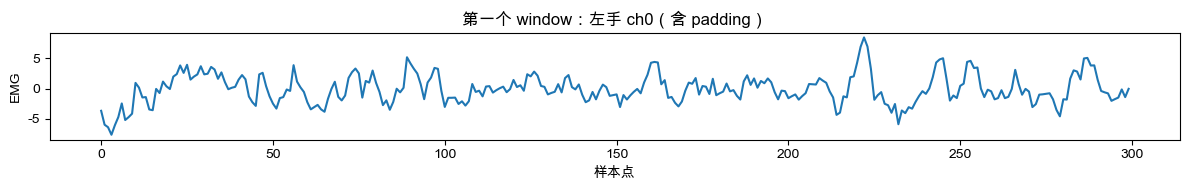

In [ ]:
# WindowedEMGDataset：按固定窗长切出的 (EMG, 标签) 样本，与训练时一致
from emg2qwerty.data import WindowedEMGDataset
from emg2qwerty.transforms import ToTensor
from emg2qwerty.charset import charset

# 与 config/model/tds_conv_ctc.yaml 一致：4s 窗、padding 用于上下文
WINDOW_LENGTH = 8000   # 2kHz * 4s
STRIDE = 4000          # 滑动步长（可重叠）
PADDING = (1800, 200)  # 左 900ms、右 100ms 上下文

windowed = WindowedEMGDataset(
    hdf5_path,
    window_length=WINDOW_LENGTH,
    stride=STRIDE,
    padding=PADDING,
    jitter=False,
    transform=ToTensor(),
)
print("WindowedEMGDataset 样本数:", len(windowed))
print("window_length =", WINDOW_LENGTH, ", stride =", STRIDE, ", padding =", PADDING)

# 取前 3 个 window 样例
for i in range(min(3, len(windowed))):
    emg, labels = windowed[i]
    # emg: (T, 2, 16) 原始 EMG；labels: (L,) 该窗内按键的 label id
    text = charset().labels_to_str(labels.tolist()) if labels.numel() > 0 else "(无按键)"
    print(f"\n--- 样本 {i} ---")
    print("  EMG shape:", emg.shape, "  labels shape:", labels.shape)
    print("  解码文本:", repr(text))

# 画第一个 window 的左手 ch0 波形
emg0, _ = windowed[0]
plt.figure(figsize=(12, 2))
plt.plot(emg0[:, 0, 0].numpy())
plt.xlabel("样本点"); plt.ylabel("EMG"); plt.title("第一个 window：左手 ch0（含 padding）")
plt.tight_layout(); plt.show()

In [11]:
# 标注：keystrokes（按键级）和 prompts（句子级）
print("Keystrokes 条数:", len(session.keystrokes))
print("Prompts 条数:", len(session.prompts))
if session.keystrokes:
    print("\n前 3 条 keystroke 示例:", session.keystrokes[:3])
if session.prompts:
    print("\n前 2 条 prompt 示例:", session.prompts[:2])

Keystrokes 条数: 4627
Prompts 条数: 154

前 3 条 keystroke 示例: [{'ascii': 116, 'key': 't', 'start': 1622682802.7727966, 'end': 1622682802.8308256}, {'ascii': 104, 'key': 'h', 'start': 1622682802.8457928, 'end': 1622682803.0107927}, {'ascii': 101, 'key': 'e', 'start': 1622682803.0258288, 'end': 1622682803.1459117}]

前 2 条 prompt 示例: [{'name': 'Intro', 'start': 1622682789.6708844, 'end': 1622682801.2709928, 'payload': None, 'payload_type': None}, {'name': 'text_prompt', 'start': 1622682801.296628, 'end': 1622682817.3542345, 'payload': {'prompt_num': 0, 'text': 'the quick brown fox jumps over a lazy dog⏎'}, 'payload_type': 'text_prompt'}]


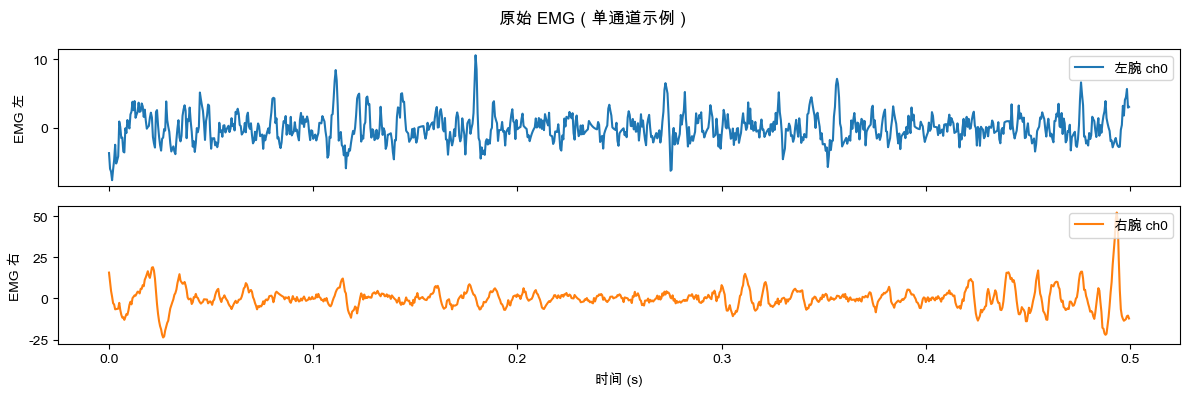

In [12]:
# 画一小段 EMG：2kHz 采样，画 0.5 秒 = 1000 点
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 4))
t = np.arange(1000) / 2000  # 秒
axes[0].plot(t, chunk["emg_left"][:1000, 0], label="左腕 ch0")
axes[0].set_ylabel("EMG 左")
axes[0].legend(loc="upper right")
axes[1].plot(t, chunk["emg_right"][:1000, 0], label="右腕 ch0", color="C1")
axes[1].set_ylabel("EMG 右")
axes[1].set_xlabel("时间 (s)")
axes[1].legend(loc="upper right")
plt.suptitle("原始 EMG（单通道示例）")
plt.tight_layout()
plt.show()

ToTensor 后 shape: torch.Size([8000, 2, 16])
LogSpectrogram 后 shape: torch.Size([497, 2, 16, 33])


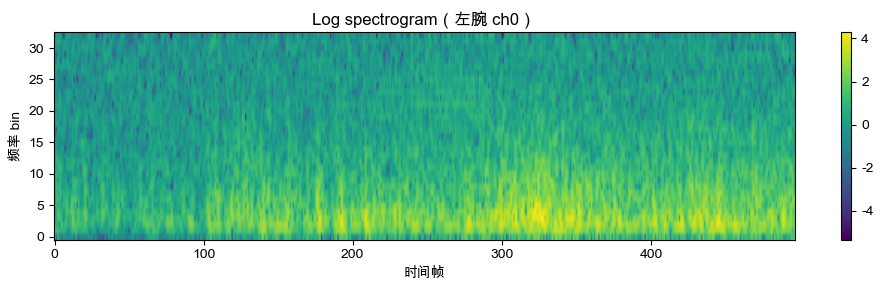

In [13]:
# 可选：看 transform 后的样子（和训练时一致）
from emg2qwerty.transforms import ToTensor, LogSpectrogram

to_tensor = ToTensor(fields=["emg_left", "emg_right"])
logspec = LogSpectrogram(n_fft=64, hop_length=16)
raw = session[:8000]  # 4s 窗口
x = to_tensor(raw)    # (T, 2, 16)：时间, 左右手, 通道
x = logspec(x)        # (T', 2, 16, 33)：时间帧, 左右手, 通道, 频率 bin
print("ToTensor 后 shape:", to_tensor(raw).shape)
print("LogSpectrogram 后 shape:", x.shape)
# 画左腕、单通道的 log spectrogram（时间帧 x 频率）
plt.figure(figsize=(10, 3))
plt.imshow(x[:, 0, 0, :].T.detach().numpy(), aspect="auto", origin="lower")
plt.colorbar()
plt.xlabel("时间帧"); plt.ylabel("频率 bin")
plt.title("Log spectrogram（左腕 ch0）")
plt.tight_layout()
plt.show()